# <b>Handwritten Numbers Recognition</b>

# 1. Import Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from numpy import unique
from numpy import reshape
from keras.models import Sequential
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation, Dropout
from keras.utils import to_categorical
from keras.datasets import mnist
from numpy import argmax
from PIL import Image
from numpy import asarray

In [2]:
tf.random.set_seed(42)

In [3]:
hand = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


# 2. Train Model on MINIST Data

In [4]:
hand[0]

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [5]:
(X_train, y_train), (X_test, y_test) = hand

In [6]:
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 180000

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [9]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

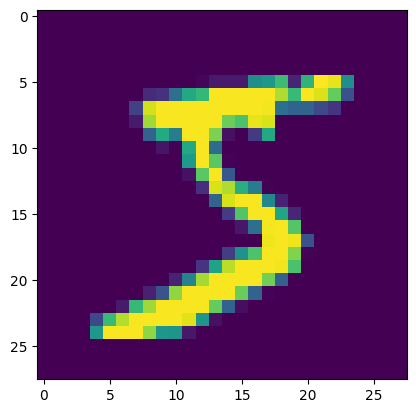

In [10]:
plt.imshow(X_train[0])

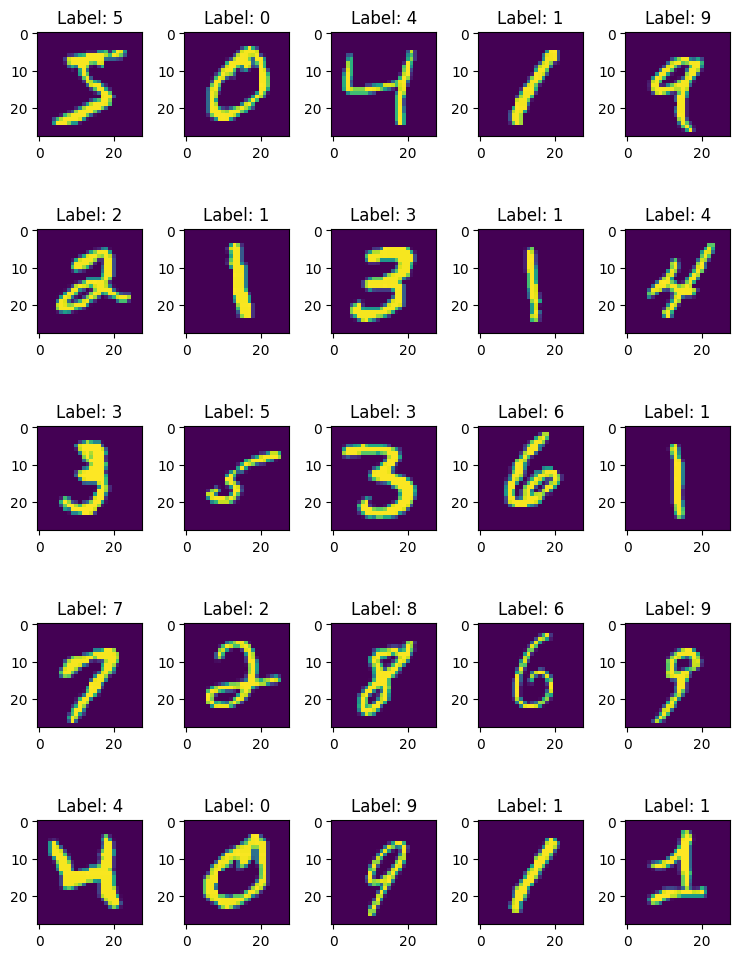

In [11]:
num = 25
images = X_train[:num]
labels = y_train[:num]

num_row = 5
num_col = 5
# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(images[i])#, cmap='gray')
    ax.set_title('Label: {}'.format(labels[i]))
plt.tight_layout()
plt.show()

In [12]:
# Preprocess input data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [13]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [14]:
X_train /= 255
X_test /= 255

In [15]:
# Preprocess class labels
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [16]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

In [17]:
for label in range(10):
    one_hot = (Y_train[label]).astype(np.int32)
    print("label: ", label, " in one-hot representation: ", one_hot)

label:  0  in one-hot representation:  [0 0 0 0 0 1 0 0 0 0]
label:  1  in one-hot representation:  [1 0 0 0 0 0 0 0 0 0]
label:  2  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]
label:  3  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  4  in one-hot representation:  [0 0 0 0 0 0 0 0 0 1]
label:  5  in one-hot representation:  [0 0 1 0 0 0 0 0 0 0]
label:  6  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  7  in one-hot representation:  [0 0 0 1 0 0 0 0 0 0]
label:  8  in one-hot representation:  [0 1 0 0 0 0 0 0 0 0]
label:  9  in one-hot representation:  [0 0 0 0 1 0 0 0 0 0]


In [18]:
# Set timesteps, input and number of classes
epochs = 30
batch_size = 16
n_hidden = 32

# Define model architecture
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [19]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
# Fit model on training data
model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1)

Epoch 1/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.2184 - accuracy: 0.9340
Epoch 2/10
1875/1875 [==============================] - 20s 11ms/step - loss: 0.0908 - accuracy: 0.9729
Epoch 3/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0699 - accuracy: 0.9780
Epoch 4/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0551 - accuracy: 0.9824
Epoch 5/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.0488 - accuracy: 0.9850
Epoch 6/10
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0438 - accuracy: 0.9862
Epoch 7/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.0382 - accuracy: 0.9883
Epoch 8/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0354 - accuracy: 0.9888
Epoch 9/10
1875/1875 [==============================] - 24s 13ms/step - loss: 0.0310 - accuracy: 0.9899
Epoch 10/10
1875/1875 [==============================] - 23s 13m

# 3. Predict My Handwritten Numbers

In [25]:
# Define path
numbers_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/Handwriting Numbers"

In [28]:
# Import required libraries first
from PIL import Image
import os

# Check if file exists before opening
filename = "4.jpg"
file_path = os.path.join(numbers_path, filename)

# Verify the file exists
if os.path.exists(file_path):
    img = Image.open(file_path)
    print(img.format)
    print(img.size)
    print(img.mode)
else:
    print(f"File not found: {file_path}")
    # Optional: List files in the directory to check what's available
    if os.path.exists(numbers_path):
        print(f"Files in directory: {os.listdir(numbers_path)}")
    else:
        print(f"Directory does not exist: {numbers_path}")

JPEG
(2000, 2000)
L


In [29]:
# Predict the digit for the test image (4)
filename = "4.jpg"
file_path = os.path.join(numbers_path, filename)

img = Image.open(file_path)                 
img2 = img.resize((28, 28))                

testimg = np.asarray(img2).astype("float32") / 255.0
testimg = testimg.reshape(1, 28, 28, 1)

pred = model.predict(testimg)
digit = int(np.argmax(pred, axis=1)[0])

print("Predicted digit:", digit)

1/1 [==============================] - 0s 151ms/step
Predicted digit: 4


In [32]:
# Run predictions for all numbers
results = []
files = [f for f in os.listdir(numbers_path) if f.lower().endswith((".jpg", ".jpeg"))]

# Sort numerically by filename stem 
files = sorted(files, key=lambda f: int(os.path.splitext(f)[0]) if os.path.splitext(f)[0].isdigit() else 999)

for f in files:
    stem = os.path.splitext(f)[0]
    if not stem.isdigit():
        continue
    
    true_label = int(stem)

    img = Image.open(os.path.join(numbers_path, f)).resize((28, 28))  
    arr = np.asarray(img).astype("float32") / 255.0
    arr = arr.reshape(1, 28, 28, 1)

    pred = model.predict(arr, verbose=0)
    pred_label = int(np.argmax(pred, axis=1)[0])

    results.append([f, true_label, pred_label, "Yes" if true_label == pred_label else "No"])

In [33]:
# Print a readable table
print("File\tTrue\tPredicted\tCorrect")
for r in results:
    print(f"{r[0]}\t{r[1]}\t{r[2]}\t\t{r[3]}")

accuracy = sum(1 for r in results if r[3] == "Yes") / len(results) if results else 0
print(f"\nAccuracy: {accuracy:.2%} ({sum(1 for r in results if r[3]=='Yes')}/{len(results)})")

File	True	Predicted	Correct
0.jpg	0	9		No
1.jpg	1	1		Yes
2.jpg	2	2		Yes
3.jpg	3	9		No
4.jpg	4	4		Yes
5.jpg	5	5		Yes
6.jpg	6	6		Yes
7.jpg	7	7		Yes
8.jpg	8	3		No
9.jpg	9	9		Yes

Accuracy: 70.00% (7/10)


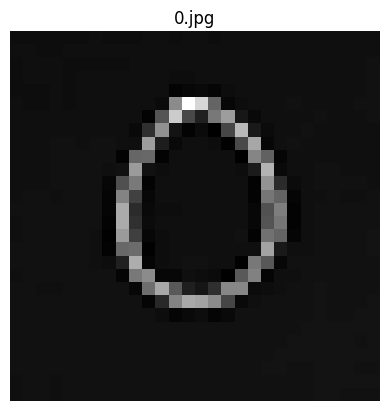

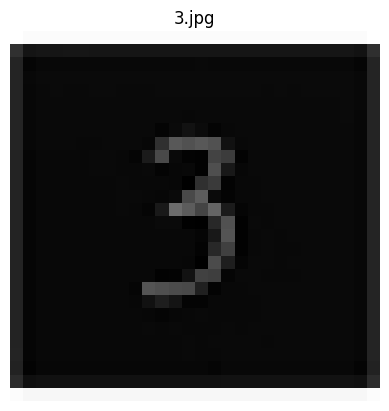

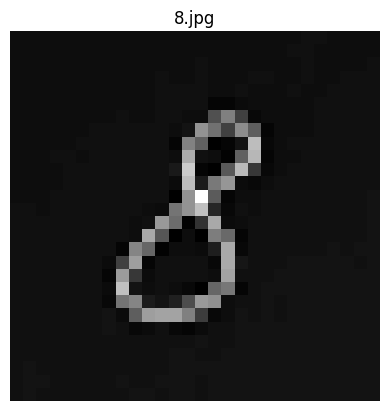

In [34]:
# Double check the mis-predicted visuals

def show_digit(fname):
    img = Image.open(os.path.join(numbers_path, fname)).resize((28,28))
    arr = np.asarray(img)
    plt.imshow(arr, cmap="gray")
    plt.title(fname)
    plt.axis("off")
    plt.show()

show_digit("0.jpg")
show_digit("3.jpg")
show_digit("8.jpg")


## Observation:
- The MNIST-trained model correctly classified 7 out of 10 handwritten digits (70% accuracy).
- The misclassified digits (0, 3, and 8) were clearly written and visually unambiguous, indicating errors were not due to handwriting quality.
- These errors likely result from representation loss during resizing and pixel-level feature sensitivity, rather than human-perceived ambiguity.
- The results illustrate how image-based models depend on learned visual patterns, which may not fully generalize to real-world inputs even with correct preprocessing.
- Overall, the exercise demonstrates both the effectiveness and limitations of applying pretrained image classifiers to real-world handwritten data.